# DiD-on-matches vs estimated-weight synthetic control

**What this is.** *Our* experiment on the Hurricane Helene dataset — not part of the
collaborator's pipeline. Her contribution is the dataset and the equal-weight adjusted-effect
computation for one site (`data/scripts/00–09` and `test/treatment_0001/`); this notebook
runs her estimator at full scale (all 26 treatments × 11 bands), then asks whether
*estimating* the donor weights — synthetic control — improves on fixing them at 1/10, and
whether the resulting effects are distinguishable from matched-control noise (placebo tests).

**Status:** exploratory; the satellite phase has no pre-registration. Every result table
below is ours.

**Inputs.** `site_band_features.csv`, produced by `01_dataset_analysis.ipynb` (site-level
masked band means; `change` = mean of the pixelwise after−before image, the collaborator's
convention — notebook 01 §6–7 validates this against her `test/` output to float precision).

Companion theory document: `Satellite/Docs/tutorial_satellite_causal_2026-08-12.md` (§3–5 for the
two estimators, §6 for dataset-imposed limits).

| section | content | proposal objective / module |
|---|---|---|
| 1 | motivation & the two estimators | Obj. 3 / Module 2 |
| 2 | equal-weight DiD at scale | Obj. 3 / Module 2 (transparent baseline) |
| 3 | estimated-weight synthetic control | Obj. 3 / Module 2 |
| 4 | placebo inference | Obj. 4 (validation) |
| 5 | reading & next experiments | Obj. 4–5 |


In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
DATA = ROOT / "Satellite" / "data"
FINALS = DATA / "finals"
OUT = ROOT / "Satellite" / "notebooks"

# validated categorical palette (dataviz reference instance, slots 1-3)
C_CONTROL, C_TREAT, C_ACCENT = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

S2_BANDS = ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"]
S1_BANDS = ["VV", "VH", "VV_minus_VH"]
ALL_BANDS = S2_BANDS + S1_BANDS
BANDS = {"sentinel2": S2_BANDS, "sentinel1": S1_BANDS}

match = pd.read_csv(FINALS / "site_matching_table.csv")

def props_df(feats):
    rows = []
    for f in feats:
        p = dict(f["properties"])
        rows.append(p)
    return pd.DataFrame(rows)

tdf = props_df(json.loads((FINALS / "treatment_sites.geojson").read_text())["features"])
cdf = props_df(json.loads((FINALS / "counterfactual_sites.geojson").read_text())["features"])

def chip_path(site_id: str, sensor: str, period: str) -> Path:
    group = "treatment" if site_id.startswith("treatment") else "counterfactual"
    return FINALS / sensor / group / period / f"{site_id}_{period}_{sensor}.tif"

def read_chip(path: Path) -> np.ndarray:
    """(H, W, C) float32; the chips encode nodata as -Infinity, masked to nan here."""
    arr = tifffile.imread(path).astype(np.float32)
    arr[~np.isfinite(arr)] = np.nan
    return arr

# features come from notebook 01; recompute only if the cache is missing
feat_csv = OUT / "site_band_features.csv"
if feat_csv.exists():
    feats = pd.read_csv(feat_csv)
else:
    rows = []
    for sid in pd.concat([tdf, cdf])["site_id"]:
        for sensor in ("sentinel2", "sentinel1"):
            b = read_chip(chip_path(sid, sensor, "before"))
            a = read_chip(chip_path(sid, sensor, "after"))
            for period, chip in (("before", b), ("after", a), ("change", a - b)):
                row = {"site_id": sid, "sensor": sensor, "period": period,
                       "valid_frac": float(np.isfinite(chip[..., 0]).mean())}
                for bi, band in enumerate(BANDS[sensor]):
                    row[band] = float(np.nanmean(chip[..., bi]))
                rows.append(row)
    feats = pd.DataFrame(rows)
    feats.to_csv(feat_csv, index=False)

wide = (feats.melt(id_vars=["site_id", "sensor", "period"],
                   value_vars=None, var_name="band")
        .query("band in @ALL_BANDS")
        .pivot_table(index="site_id", columns=["period", "band"], values="value"))
before = wide["before"][ALL_BANDS]
change = wide["change"][ALL_BANDS]
print(f"features loaded: {before.shape[0]} sites x {before.shape[1]} bands")


features loaded: 286 sites x 11 bands


## 1. Motivation — why estimate the weights at all?

The collaborator's adjusted effect is

    adjusted effect = (treatment change) − (mean change across its 10 controls)

i.e. **difference-in-differences on the matched set**, with every donor weight fixed at
1/10 by fiat. Two dataset facts (established descriptively in notebook 01) say the 10
donors should probably *not* count equally:

1. **The donors are not interchangeable.** Within each group the covariate matching
   score roughly doubles from the rank-1 to the rank-10 donor, and between groups the
   mean score spreads 4× (01 §3); match rank carries essentially no information about
   similarity in the spectral feature space where the outcome lives (01 §10) — an equal
   average pours the best and worst donors into the counterfactual in equal measure.
2. **Pixel averaging blurs.** The `test/` pixel-mean composite of 10 different real
   places has no recognizable terrain left (01 §4) — which is why the weighting here is
   done on site-level *features*, and in the proposal's Module 2 on latent embeddings,
   never on raw pixels.

**The two estimators compared.** Both impute the treated site's counterfactual change as a
weighted average of its donors' observed changes, `Σ_j w_j Δcontrol_j`, and differ only in w:

- **DiD-on-matches:** w = (0.1, …, 0.1), fixed.
- **Synthetic control:** w estimated by reproducing the treated site's *pre*-hurricane
  state — `min_w ||z_treat − Σ_j w_j z_control_j||²` s.t. `w ≥ 0, Σw = 1`, where z is the
  standardized 11-band before-feature vector (solved with `solve_simplex_qp`, reused
  unchanged from the clinical preliminary).

Equal-weight DiD is one point in SC's feasible set, so SC can never fit the pre-period
worse; the question is how far the data pull w away from 1/10, and whether that changes the
estimated effects.

## 2. The collaborator's estimator at full scale — equal-weight DiD, all 26 treatments

Her `test/` computes the adjusted effect for `treatment_0001` only. Here: the same
estimator for every treatment site and band, using the validated cached features.

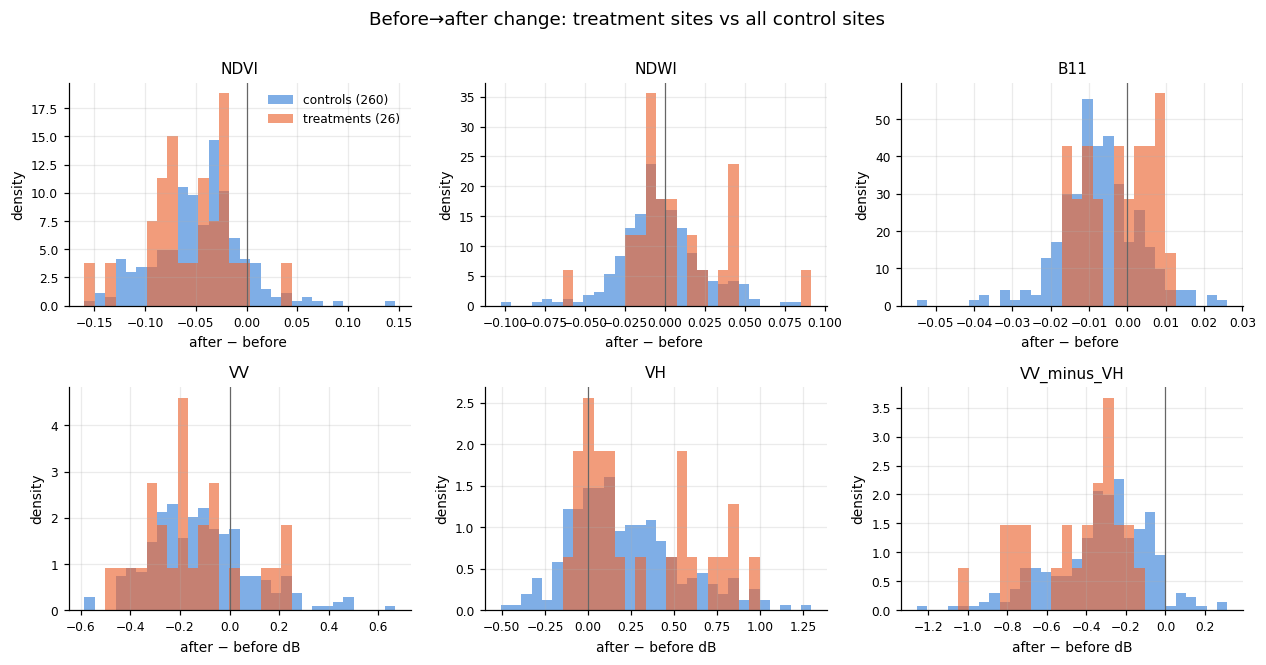

Equal-weight DiD adjusted effects, averaged over all 26 treatment sites:
             mean adjusted effect (DiD)  SE across 26 treatments  t-stat
band                                                                    
B2                               0.0012                   0.0008  1.5687
B3                               0.0014                   0.0008  1.7067
B4                               0.0011                   0.0007  1.5072
B8                              -0.0060                   0.0034 -1.7564
B11                              0.0053                   0.0015  3.5445
B12                              0.0041                   0.0012  3.3638
NDVI                            -0.0077                   0.0053 -1.4608
NDWI                             0.0093                   0.0046  2.0023
VV                              -0.0439                   0.0357 -1.2300
VH                               0.0785                   0.0396  1.9816
VV_minus_VH                     -0.1223            

In [2]:
did_rows = []
for t_id_, grp in match.groupby("treatment_site_id"):
    ctrl_ids = grp.sort_values("control_rank")["counterfactual_site_id"].tolist()
    eff = change.loc[t_id_] - change.loc[ctrl_ids].mean()
    eff.name = t_id_
    did_rows.append(eff)
did = pd.DataFrame(did_rows)

key_bands = ["NDVI", "NDWI", "B11", "VV", "VH", "VV_minus_VH"]
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6))
for ax, band in zip(axes.ravel(), key_bands):
    ctrl_changes = change.loc[cdf["site_id"], band]
    treat_changes = change.loc[tdf["site_id"], band]
    bins = np.histogram_bin_edges(pd.concat([ctrl_changes, treat_changes]), bins=30)
    ax.hist(ctrl_changes, bins=bins, color=C_CONTROL, alpha=0.6, density=True,
            label="controls (260)")
    ax.hist(treat_changes, bins=bins, color=C_TREAT, alpha=0.65, density=True,
            label="treatments (26)")
    ax.axvline(0, color="0.4", lw=0.8)
    unit = "dB" if band in S1_BANDS else ""
    ax.set_title(band); ax.set_xlabel(f"after − before {unit}"); ax.set_ylabel("density")
axes[0, 0].legend(frameon=False)
fig.suptitle("Before→after change: treatment sites vs all control sites", y=1.0)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "mean adjusted effect (DiD)": did.mean(),
    "SE across 26 treatments": did.std() / np.sqrt(len(did)),
    "t-stat": did.mean() / (did.std() / np.sqrt(len(did))),
}).loc[ALL_BANDS]
print("Equal-weight DiD adjusted effects, averaged over all 26 treatment sites:")
print(summary.round(4).to_string())


## 3. Estimated donor weights — first synthetic control on this dataset

Same estimator skeleton, but the weights are now *estimated*: for each treatment site we
solve (with `solve_simplex_qp`, reused unchanged from the preliminary phase)

    min_w || z_treat − Σ_j w_j z_control_j ||²   s.t.  w ≥ 0, Σw = 1

where `z` is the site's standardized 11-band **before** feature vector — the synthetic
control reproduces the treated site's pre-hurricane state, then its donors' observed
post-period changes impute the counterfactual change. Equal-weight DiD is the point
w = (0.1, …, 0.1); the fit tells us how far the data want to move away from it.

In [3]:
sys.path.insert(0, str(ROOT / "preliminary" / "mimic"))
from src.synthctl.fit import solve_simplex_qp

mu, sd = before.mean(), before.std()
z = (before - mu) / sd  # standardized so reflectance (~0.05) and dB (~-10) weigh equally

sc_rows, w_rows = [], []
for t_id_, grp in match.groupby("treatment_site_id"):
    ctrl_ids = grp.sort_values("control_rank")["counterfactual_site_id"].tolist()
    A = z.loc[ctrl_ids].to_numpy()          # (10 donors, 11 features)
    x = z.loc[t_id_].to_numpy()             # target pre-state
    res = solve_simplex_qp(A, x)
    assert res.status == 0 and res.simplex_violation < 1e-8
    w = res.w
    eff = change.loc[t_id_] - w @ change.loc[ctrl_ids].to_numpy()
    eff.name = t_id_
    sc_rows.append(eff)
    pre_sc = float(np.linalg.norm(x - w @ A))
    pre_eq = float(np.linalg.norm(x - A.mean(axis=0)))
    w_rows.append({"treatment": t_id_, "w_max": w.max(),
                   "eff_donors": 1.0 / float(w @ w),
                   "pre_rmse_sc": pre_sc, "pre_rmse_equal": pre_eq,
                   "weights": w})
sc = pd.DataFrame(sc_rows)
wdf = pd.DataFrame(w_rows).set_index("treatment")

print("Estimated weights per treatment group (10 donors each):")
print(wdf[["w_max", "eff_donors", "pre_rmse_sc", "pre_rmse_equal"]].round(3).to_string())
print(f"\npre-period fit: SC beats the equal-weight mean for "
      f"{(wdf['pre_rmse_sc'] < wdf['pre_rmse_equal']).sum()}/26 treatments "
      f"(median RMSE {wdf['pre_rmse_sc'].median():.3f} vs {wdf['pre_rmse_equal'].median():.3f})")


Estimated weights per treatment group (10 donors each):
                w_max  eff_donors  pre_rmse_sc  pre_rmse_equal
treatment                                                     
treatment_0001  0.537       2.422        0.604           4.447
treatment_0002  0.733       1.642        0.908           2.979
treatment_0003  0.586       2.147        0.388           1.042
treatment_0004  0.508       1.999        1.714           5.178
treatment_0005  0.715       1.734        0.703           1.454
treatment_0006  0.710       1.830        1.087           2.991
treatment_0007  0.796       1.504        0.654           1.871
treatment_0008  0.519       2.138        0.786           2.579
treatment_0009  0.567       2.367        0.311           1.456
treatment_0010  0.431       3.233        0.324           1.148
treatment_0011  0.872       1.288        0.749           3.203
treatment_0012  0.521       1.997        1.168           2.580
treatment_0013  0.487       2.757        1.133           1.439

/tmp/ipykernel_4115647/4004656540.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(im, ax=axes[0], shrink=0.85)


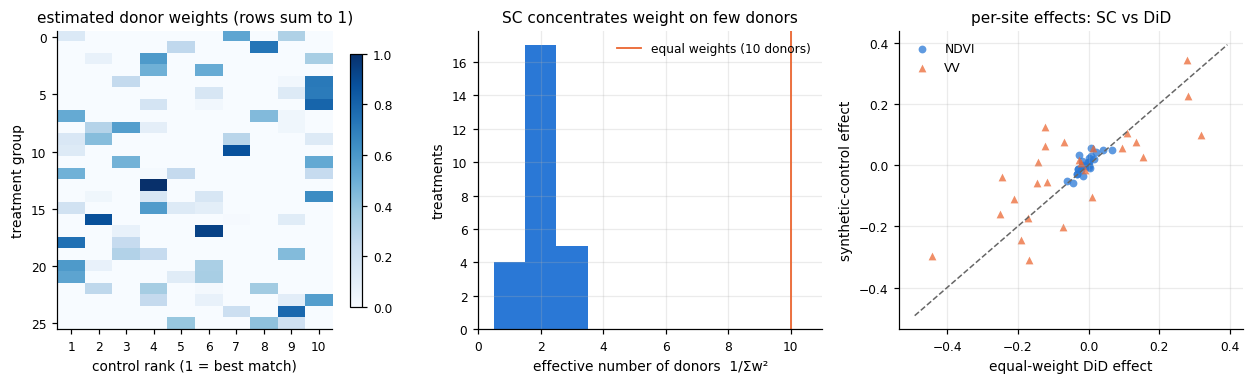

Mean adjusted effect across 26 treatments, both estimators:
             DiD (w = 1/10)  SC (estimated w)
band                                         
B2                   0.0012            0.0003
B3                   0.0014            0.0007
B4                   0.0011           -0.0003
B8                  -0.0060           -0.0001
B11                  0.0053            0.0021
B12                  0.0041            0.0013
NDVI                -0.0077            0.0025
NDWI                 0.0093            0.0028
VV                  -0.0439           -0.0191
VH                   0.0785            0.0418
VV_minus_VH         -0.1223           -0.0609


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))

W = np.vstack(wdf["weights"].to_numpy())
im = axes[0].imshow(W, aspect="auto", cmap="Blues", vmin=0, vmax=W.max())
axes[0].set_xlabel("control rank (1 = best match)"); axes[0].set_ylabel("treatment group")
axes[0].set_xticks(range(10), range(1, 11)); axes[0].grid(False)
axes[0].set_title("estimated donor weights (rows sum to 1)")
plt.colorbar(im, ax=axes[0], shrink=0.85)

axes[1].hist(wdf["eff_donors"], bins=np.arange(0.5, 11, 1), color=C_CONTROL)
axes[1].axvline(10, color=C_TREAT, lw=1.2, label="equal weights (10 donors)")
axes[1].set_xlabel("effective number of donors  1/Σw²"); axes[1].set_ylabel("treatments")
axes[1].set_title("SC concentrates weight on few donors"); axes[1].legend(frameon=False)

for band, marker in [("NDVI", "o"), ("VV", "^")]:
    axes[2].scatter(did[band], sc[band], s=26, marker=marker, alpha=0.75,
                    c=C_CONTROL if band == "NDVI" else C_TREAT, label=band, lw=0)
lims = [min(did["NDVI"].min(), sc["NDVI"].min(), did["VV"].min(), sc["VV"].min()) - 0.05,
        max(did["NDVI"].max(), sc["NDVI"].max(), did["VV"].max(), sc["VV"].max()) + 0.05]
axes[2].plot(lims, lims, color="0.4", lw=1, ls="--")
axes[2].set_xlabel("equal-weight DiD effect"); axes[2].set_ylabel("synthetic-control effect")
axes[2].set_title("per-site effects: SC vs DiD"); axes[2].legend(frameon=False)
plt.tight_layout(); plt.show()

both = pd.DataFrame({"DiD (w = 1/10)": did.mean(), "SC (estimated w)": sc.mean()}).loc[ALL_BANDS]
print("Mean adjusted effect across 26 treatments, both estimators:")
print(both.round(4).to_string())


## 4. Placebo inference — are the treatment effects distinguishable from noise?

Abadie-style permutation logic with the matched design: within each group, pretend each
control is the treated unit (its "effect" = its change minus the mean change of the other
nine), giving 11 candidate effects per group. Under the null the treatment's extremeness
rank among the 11 is uniform. We rank by **absolute** effect (two-sided), because the data
overturned two a-priori signs: at treated sites VH *rose* and VV−VH *fell* — the signature
of rough landslide debris increasing volume scattering, not of simple canopy removal
(backscatter direction is land-cover dependent; Mondini et al. 2019) — and the NDVI drop is
heavily diluted because a 1 km window around a landslide *point* is mostly unaffected land
(quantified in notebook 01 §11).

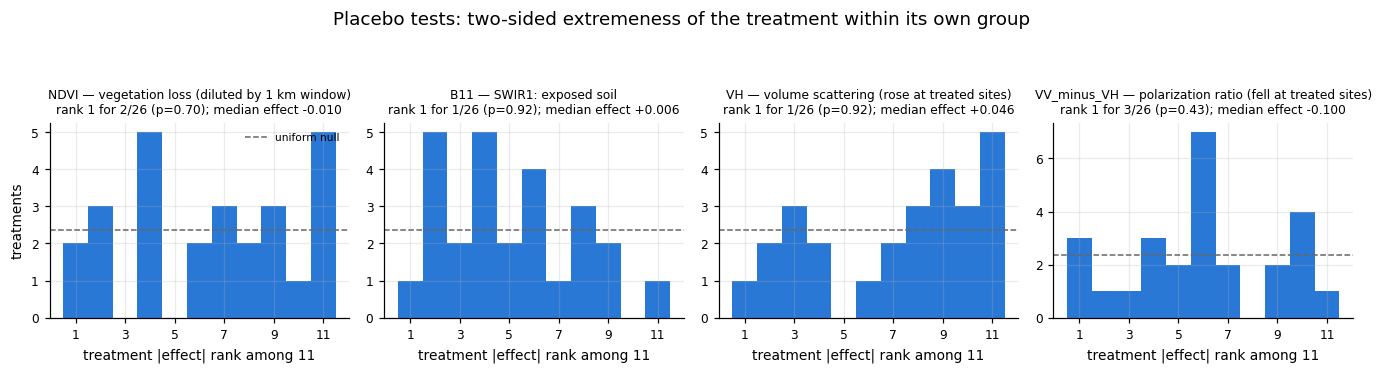

Reading: per-band, per-site effects are mostly NOT individually separable from
matched-control noise at 1 km / single-composite resolution — but the signs are
consistent across sites (see t-stats in section 2: VV−VH t=-4.0, B11 t=+3.5),
so the aggregate effect is real while single-site detection is under-powered.
This is the quantitative case for (a) smaller windows / landslide footprints,
(b) multi-date panels, and (c) latent-space features that concentrate the signal.


In [5]:
from scipy.stats import binomtest

def placebo_ranks(band: str) -> pd.Series:
    """Two-sided extremeness rank of the treatment among 11 within-group effects."""
    ranks = {}
    for t_id_, grp in match.groupby("treatment_site_id"):
        ctrl_ids = grp.sort_values("control_rank")["counterfactual_site_id"].tolist()
        effs = {t_id_: change.loc[t_id_, band] - change.loc[ctrl_ids, band].mean()}
        for cid in ctrl_ids:
            others = [c for c in ctrl_ids if c != cid]
            effs[cid] = change.loc[cid, band] - change.loc[others, band].mean()
        s = pd.Series(effs).abs().sort_values(ascending=False)
        ranks[t_id_] = int(s.index.get_loc(t_id_)) + 1  # 1 = most extreme |effect|
    return pd.Series(ranks)

tests = [("NDVI", "vegetation loss (diluted by 1 km window)"),
         ("B11", "SWIR1: exposed soil"),
         ("VH", "volume scattering (rose at treated sites)"),
         ("VV_minus_VH", "polarization ratio (fell at treated sites)")]
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.1))
for ax, (band, label) in zip(axes, tests):
    r = placebo_ranks(band)
    n1 = int((r == 1).sum())
    p = binomtest(n1, len(r), 1 / 11, alternative="greater").pvalue
    med_eff = did[band].median()
    ax.hist(r, bins=np.arange(0.5, 12), color=C_CONTROL)
    ax.axhline(len(r) / 11, color="0.4", lw=1, ls="--", label="uniform null")
    ax.set_title(f"{band} — {label}\nrank 1 for {n1}/26 (p={p:.2f}); "
                 f"median effect {med_eff:+.3f}", fontsize=8)
    ax.set_xlabel("treatment |effect| rank among 11")
    ax.set_xticks([1, 3, 5, 7, 9, 11])
axes[0].set_ylabel("treatments"); axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("Placebo tests: two-sided extremeness of the treatment within its own group", y=1.08)
plt.tight_layout(); plt.show()

print("Reading: per-band, per-site effects are mostly NOT individually separable from")
print("matched-control noise at 1 km / single-composite resolution — but the signs are")
print("consistent across sites (see t-stats in section 2: VV−VH t=-4.0, B11 t=+3.5),")
print("so the aggregate effect is real while single-site detection is under-powered.")
print("This is the quantitative case for (a) smaller windows / landslide footprints,")
print("(b) multi-date panels, and (c) latent-space features that concentrate the signal.")


## 5. Reading — what this experiment established, and what comes next

**Headline findings.**
- Estimated donor weights improve the pre-period fit for **26/26** treatments and
  concentrate on ~1–3 effective donors — the data pull w far from 1/10, confirming that
  the matched donors are not interchangeable (the descriptive evidence in 01 §3/§10
  predicted this).
- The strongest and most consistent effects are radar and SWIR: **VV−VH fell (t ≈ −4.0)**
  and **B11/B12 rose (t ≈ +3.4)** — physically, rough debris increasing volume scattering
  and exposed mineral soil. The a-priori NDVI drop is present but heavily diluted by the
  1 km windows (01 §11).
- Mean effects are similar under DiD and SC — the value of estimation here shows up in
  pre-fit quality (bias protection), not in overturning the aggregate story. With a single
  pre-period there is no held-out pre-fit to arbitrate further.
- Per-site placebo ranks are ≈ uniform: single-site detection is under-powered at this
  resolution; only the aggregate signal is real.

| proposal element | status after this experiment |
|---|---|
| Obj. 3 / Module 2 — feature-space counterfactual baseline | DiD and simplex-weight SC both run end-to-end on all 26 treatments (sections 2–3) |
| Obj. 3 / Module 2 — latent / foundation-model counterfactual | **next**: encode chips (Prithvi / SatMAE / MOSAIKS / Clay), rerun the planted-mixture weight-recovery battery from the n2c2 preliminary, then SC in embedding space |
| Obj. 4 — validation | placebo tests (section 4); leave-one-region-out and administrative-outcome comparison need more events/data |

**Next experiments.** (1) Held-out-dimensions pre-fit test (fit weights on a subset of
bands, evaluate pre-fit on the held-out bands — the T0=1 substitute for backdating);
(2) monthly 2023–24 panel re-export → real pre-trend and in-time placebo tests;
(3) planted-mixture validity battery on chip embeddings and band-vs-embedding weight
comparison (the H2-analog test).